# Laboratorio 4. Parte 2 — Análisis de modelos usando datos geoespaciales
### CC3084 — Data Science | UVG | Semestre II - 2026
**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git


## Ejercicio 1. Preparación de los datos para Machine Learning

Partimos de los raster descargados en la Parte I (`data/raster/<lago>/<lago>_<fecha>.tif`
con bandas `B03`, `B04`, `B08`, y `data/raster/<lago>/<lago>_<fecha>_B05.tif`), usando
las mismas 11 fechas por lago. Este notebook asume que la Parte I ya se ejecutó y que
esos archivos existen en disco.

Cada fila del dataset de Machine Learning representará **un píxel de agua válido** de
una imagen (lago, fecha), con sus coordenadas, bandas espectrales, índices (NDVI, NDWI)
y el índice de cianobacteria (Chl-a) asociado.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import transform as warp_transform
import matplotlib.pyplot as plt
import seaborn as sns

RASTER_DIR = Path("data/raster")
OUT_DIR = Path("data")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# --- Mismas fechas y lagos utilizados en la Parte I ---
fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21",
    "2025-12-29", "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28",
    "2026-07-22",
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08",
    "2026-02-02", "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28",
    "2026-06-19",
]

fechas_por_lago = {
    "atitlan": fechas_atitlan,
    "amatitlan": fechas_amatitlan,
}

for lago, fechas in fechas_por_lago.items():
    print(f"{lago}: {len(fechas)} fechas oficiales")

atitlan: 11 fechas oficiales
amatitlan: 11 fechas oficiales


### 1.1–1.2 Construcción del dataset a nivel de píxel

Para cada imagen (lago, fecha) leemos las bandas `B03`, `B04`, `B08` (raster principal)
y `B05` (raster adicional, usado en la Parte I para el índice de cianobacteria/NDCI),
calculamos NDVI, NDWI y el índice de cianobacteria (Chl-a), y generamos las coordenadas
(longitud/latitud) de cada píxel.

Debido a la resolución de 10 m, una imagen completa tiene del orden de millones de
píxeles; para evitar un dataset excesivamente grande y con fuerte redundancia espacial
entre píxeles vecinos, submuestreamos con un `PIXEL_STRIDE` (tomamos 1 de cada N píxeles
en filas y columnas). Esto se documenta y se puede ajustar en la sección 1.6.

In [ ]:
# Funciones de lectura e índices

def leer_bandas(ruta_principal, ruta_b05):
    with rasterio.open(ruta_principal) as src:
        b03 = src.read(1).astype("float32")
        b04 = src.read(2).astype("float32")
        b08 = src.read(3).astype("float32")
        crs = src.crs
        transform = src.transform
    with rasterio.open(ruta_b05) as src2:
        b05 = src2.read(1).astype("float32")
    return b03, b04, b08, b05, crs, transform


def calcular_indices(b03, b04, b08, b05):
    NODATA = -1000
    for b in (b03, b04, b08, b05):
        b[:] = np.where(b <= NODATA, np.nan, b) / 10000.0
    b03, b04, b08, b05 = (np.clip(b, 0.0, 1.0) for b in (b03, b04, b08, b05))

    eps = 1e-6
    ndvi = (b08 - b04) / (b08 + b04 + eps)
    ndwi = (b03 - b08) / (b03 + b08 + eps)
    ndci = (b05 - b04) / (b05 + b04 + eps)

    ndci = np.clip(ndci, -1.0, 1.0)
    with np.errstate(over="ignore"):
        chl_a = 17.441 * np.exp(4.7038 * ndci)
    return b03, b04, b08, b05, ndvi, ndwi, chl_a


def mascara_agua(ndwi, umbral=0.0):
    return ndwi > umbral

In [4]:
PIXEL_STRIDE = 5  # 1 de cada 5 píxeles en filas y columnas (ver 1.6)


def construir_observaciones(lago, fecha, ruta_principal, ruta_b05, stride=PIXEL_STRIDE):
    """Devuelve un DataFrame con una fila por píxel de agua válido, con sus
    coordenadas, bandas espectrales, NDVI, NDWI e índice de cianobacteria."""
    b03, b04, b08, b05, crs, transform = leer_bandas(ruta_principal, ruta_b05)
    b03, b04, b08, b05, ndvi, ndwi, chl_a = calcular_indices(b03, b04, b08, b05)
    agua = mascara_agua(ndwi)

    # Submuestreo por stride (antes de aplicar la máscara, para mantener el
    # patrón de rejilla regular en filas/columnas)
    H, W = ndwi.shape
    filas = np.arange(0, H, stride)
    cols = np.arange(0, W, stride)
    rr, cc = np.meshgrid(filas, cols, indexing="ij")

    m = agua[rr, cc]
    # También descartamos cualquier NaN remanente (nodata / bordes) en
    # cualquiera de las bandas o índices
    validos = (
        m
        & ~np.isnan(b03[rr, cc]) & ~np.isnan(b04[rr, cc])
        & ~np.isnan(b08[rr, cc]) & ~np.isnan(b05[rr, cc])
        & ~np.isnan(ndvi[rr, cc]) & ~np.isnan(ndwi[rr, cc])
        & ~np.isnan(chl_a[rr, cc]) & np.isfinite(chl_a[rr, cc])
    )

    rr_v, cc_v = rr[validos], cc[validos]
    if rr_v.size == 0:
        return pd.DataFrame()

    # Coordenadas de cada píxel (centro), transformadas de la proyección
    # nativa del raster a lon/lat (EPSG:4326)
    xs, ys = rasterio.transform.xy(transform, rr_v, cc_v, offset="center")
    lons, lats = warp_transform(crs, "EPSG:4326", xs, ys)

    df = pd.DataFrame({
        "lago": lago,
        "fecha": fecha,
        "lon": lons,
        "lat": lats,
        "b03": b03[rr_v, cc_v],
        "b04": b04[rr_v, cc_v],
        "b08": b08[rr_v, cc_v],
        "b05": b05[rr_v, cc_v],
        "ndvi": ndvi[rr_v, cc_v],
        "ndwi": ndwi[rr_v, cc_v],
        "cianobacteria_indice": chl_a[rr_v, cc_v],
    })
    return df

In [5]:
# --- Construcción del dataset completo (todas las fechas, ambos lagos) ---
partes = []
for lago, fechas in fechas_por_lago.items():
    for fecha in fechas:
        ruta_principal = RASTER_DIR / lago / f"{lago}_{fecha}.tif"
        ruta_b05 = RASTER_DIR / lago / f"{lago}_{fecha}_B05.tif"
        if not ruta_principal.exists() or not ruta_b05.exists():
            print(f"[omitido] Faltan archivos para {lago} - {fecha}")
            continue
        df_obs = construir_observaciones(lago, fecha, ruta_principal, ruta_b05)
        print(f"{lago} - {fecha}: {len(df_obs)} observaciones válidas")
        partes.append(df_obs)

df_ml = pd.concat(partes, ignore_index=True)
df_ml["fecha"] = pd.to_datetime(df_ml["fecha"])
df_ml.to_csv(OUT_DIR / "dataset_ml_pixeles.csv", index=False)
print("\nTotal de observaciones en el dataset:", len(df_ml))
df_ml.head()

atitlan - 2025-01-18: 49085 observaciones válidas
atitlan - 2025-04-13: 49108 observaciones válidas
atitlan - 2025-05-13: 55473 observaciones válidas
atitlan - 2025-07-17: 49021 observaciones válidas
atitlan - 2025-11-21: 50461 observaciones válidas
atitlan - 2025-12-29: 54137 observaciones válidas
atitlan - 2026-02-12: 48999 observaciones válidas
atitlan - 2026-03-24: 50188 observaciones válidas
atitlan - 2026-04-13: 48974 observaciones válidas
atitlan - 2026-04-28: 52370 observaciones válidas
atitlan - 2026-07-22: 48938 observaciones válidas
amatitlan - 2025-01-28: 6323 observaciones válidas
amatitlan - 2025-04-15: 6107 observaciones válidas
amatitlan - 2025-04-28: 5934 observaciones válidas
amatitlan - 2025-11-24: 6156 observaciones válidas
amatitlan - 2026-01-08: 5720 observaciones válidas
amatitlan - 2026-02-02: 5604 observaciones válidas
amatitlan - 2026-02-07: 3148 observaciones válidas
amatitlan - 2026-03-29: 6249 observaciones válidas
amatitlan - 2026-04-13: 6308 observaciones

,lago,fecha,lon,lat,b03,b04,b08,b05,ndvi,ndwi,cianobacteria_indice
0,atitlan,2025-01-18,-91.147514,14.751164,0.3090,0.2976,0.2946,0.1593,-0.005066,0.023857,4.199745
1,atitlan,2025-01-18,-91.147061,14.749805,0.3420,0.4072,0.3216,0.2189,-0.117453,0.030741,4.238268
2,atitlan,2025-01-18,-91.169831,14.747727,0.0129,0.0032,0.0066,0.0312,0.346903,0.323060,802.223572
3,atitlan,2025-01-18,-91.169366,14.747723,0.0085,0.0023,0.0020,0.0000,-0.069751,0.618989,0.158352
4,atitlan,2025-01-18,-91.168902,14.747720,0.0096,0.0012,0.0005,0.0013,-0.411523,0.900901,21.049995


### 1.3 Observaciones eliminadas

Durante la construcción del dataset se descartaron:

- **Píxeles fuera del agua**: se usa la máscara `NDWI > 0` (misma máscara de la Parte I)
  como proxy del límite del lago, ya que no se cuenta con un polígono oficial de cada
  lago, solo el bounding box del enunciado.
- **Píxeles con NoData**: reflectancias iguales o menores al valor centinela `-1000`
  (o `NaN` tras la conversión), típicos de bordes de escena o zonas sin cobertura.
- **Píxeles con algún índice indefinido**: NDVI, NDWI o el índice de cianobacteria
  con `NaN` o valores no finitos (por ejemplo, divisiones degeneradas ya cubiertas con
  el término `eps`, pero se valida de todas formas).
- **Nubes**: no se descargó la banda de clasificación de escena (`SCL`), así que no hay
  un filtrado de nubes píxel por píxel en este dataset. La exposición a nubes ya se
  redujo en la Parte I al descargar solo imágenes con `max_cloud_cover <= 20%` y usar
  el reductor de mediana temporal por día; se documenta como limitación y se retoma en
  la sección 1.6.

### 1.4 Resumen del dataset

In [6]:
print("Total de observaciones:", len(df_ml))
print()
print("Observaciones por lago:")
display(df_ml.groupby("lago").size().rename("n_observaciones"))
print()
print("Observaciones por lago y fecha:")
display(df_ml.groupby(["lago", "fecha"]).size().rename("n_observaciones"))

Total de observaciones: 620063

Observaciones por lago:


lago
amatitlan     63309
atitlan      556754
Name: n_observaciones, dtype: int64


Observaciones por lago y fecha:


lago       fecha     
amatitlan  2025-01-28     6323
           2025-04-15     6107
           2025-04-28     5934
           2025-11-24     6156
           2026-01-08     5720
           2026-02-02     5604
           2026-02-07     3148
           2026-03-29     6249
           2026-04-13     6308
           2026-04-28     5272
           2026-06-19     6488
atitlan    2025-01-18    49085
           2025-04-13    49108
           2025-05-13    55473
           2025-07-17    49021
           2025-11-21    50461
           2025-12-29    54137
           2026-02-12    48999
           2026-03-24    50188
           2026-04-13    48974
           2026-04-28    52370
           2026-07-22    48938
Name: n_observaciones, dtype: int64

In [7]:
print("Variables disponibles y tipo de dato:")
tipos = df_ml.dtypes.rename("tipo").to_frame()
tipos["% valores faltantes"] = (df_ml.isna().mean() * 100).round(2)
display(tipos)

Variables disponibles y tipo de dato:


,tipo,% valores faltantes
lago,object,0.0
fecha,datetime64[ns],0.0
lon,float64,0.0
lat,float64,0.0
b03,float32,0.0
b04,float32,0.0
b08,float32,0.0
b05,float32,0.0
ndvi,float32,0.0
ndwi,float32,0.0


En total quedaron 620,063 puntos de agua analizados. De esos, el 556,754 son de Atitlán y solo 63,309 de Amatitlán. Atitlán al ser un lago mucho más grande en superficie, tiene sentido que al recorrer su espejo de agua salen muchos más puntos que en Amatitlán, que es bastante más pequeño. Dentro de cada lago, la cantidad de puntos por fecha es bastante pareja, con una excepción clara: la fecha 2026-02-07 de Amatitlán tiene casi la mitad de puntos que las demás fechas de ese lago.

Ninguna de las columnas del dataset tiene datos faltantes. Ya se habían descartado antes todos los píxeles con datos inválidos (nubes, bordes, valores sin sentido), así que lo que llegó a esta tabla ya viene "limpio".

### 1.5 Análisis exploratorio de las variables

In [8]:
variables_numericas = ["b03", "b04", "b08", "b05", "ndvi", "ndwi", "cianobacteria_indice"]
print("Estadísticas descriptivas:")
display(df_ml[variables_numericas].describe())

print()
print("Estadísticas por lago:")
display(df_ml.groupby("lago")[variables_numericas].describe().T)

Estadísticas descriptivas:


,b03,b04,b08,b05,ndvi,ndwi,cianobacteria_indice
count,620063.000000,620063.000000,620063.000000,620063.000000,620063.000000,620063.000000,620063.000000
mean,0.046776,0.035770,0.034205,0.038203,-0.062819,0.474679,37.487541
std,0.136445,0.135654,0.132769,0.139925,0.306254,0.247488,164.438843
min,0.000100,0.000000,0.000000,0.000000,-0.999965,0.000091,0.158075
25%,0.011800,0.003100,0.002900,0.002800,-0.113630,0.296391,13.651469
50%,0.019600,0.009000,0.007500,0.008900,-0.036231,0.442013,17.441000
75%,0.026400,0.015600,0.014500,0.016700,0.012285,0.621329,21.174229
max,1.000000,1.000000,0.999500,1.000000,0.999867,0.999983,1924.392212



Estadísticas por lago:


lago                           amatitlan        atitlan
b03                  count  63309.000000  556754.000000
                     mean       0.071945       0.043914
                     std        0.107396       0.139077
                     min        0.002200       0.000100
                     25%        0.021900       0.011400
                     50%        0.054800       0.018900
                     75%        0.072900       0.024600
                     max        1.000000       1.000000
b04                  count  63309.000000  556754.000000
                     mean       0.052345       0.033886
                     std        0.106992       0.138413
                     min        0.000900       0.000000
                     25%        0.013400       0.002700
                     50%        0.027500       0.008400
                     75%        0.045100       0.013600
                     max        1.000000       1.000000
b08                  count  63309.000000  556754.000000
                     mean       0.047671       0.032674
                     std        0.102309       0.135716
                     min        0.000000       0.000000
                     25%        0.008300       0.002700
                     50%        0.024700       0.007000
                     75%        0.040300       0.012900
                     max        0.999400       0.999500
b05                  count  63309.000000  556754.000000
                     mean       0.069435       0.034651
                     std        0.104104       0.143001
                     min        0.000000       0.000000
                     25%        0.020700       0.002500
                     50%        0.047600       0.008200
                     75%        0.075200       0.013700
                     max        1.000000       1.000000
ndvi                 count  63309.000000  556754.000000
                     mean      -0.158541      -0.051935
                     std        0.250323       0.310114
                     min       -0.999965      -0.999944
                     25%       -0.242196      -0.101790
                     50%       -0.098168      -0.032256
                     75%       -0.011236       0.014491
                     max        0.564419       0.999867
ndwi                 count  63309.000000  556754.000000
                     mean       0.372451       0.486303
                     std        0.230869       0.246639
                     min        0.000091       0.000208
                     25%        0.210454       0.310506
                     50%        0.337849       0.451720
                     75%        0.510773       0.634585
                     max        0.999983       0.999980
cianobacteria_indice count  63309.000000  556754.000000
                     mean      62.673870      34.623581
                     std       48.537731     172.530197
                     min        0.158277       0.158075
                     25%       29.413519      13.115412
                     50%       50.305302      16.829663
                     75%       75.783211      19.561172
                     max      862.105530    1924.392212

Lo primero que salta es que casi todos los valores de reflectancia (b03, b04, b08, b05 — básicamente qué tanta luz refleja el agua en distintos colores) están muy cerca de cero, tanto en promedio como en la mediana. Esto es normal en agua: el agua absorbe mucha luz y refleja poca, así que la mayoría de los píxeles de agua deberían verse "oscuros" en estos números. Pero el máximo llega hasta 1.0 en varias bandas, lo que indica que hay algunos píxeles atípicos muy brillantes — probablemente reflejos del sol sobre el agua o algún resto de nube que no se filtró del todo.

El NDVI (que normalmente se usa para detectar vegetación) da en promedio un valor negativo, lo cual es justamente lo esperado sobre agua, ya que el agua no tiene vegetación. El NDWI (que marca presencia de agua) da en promedio positivo, como debe ser, confirmando que la máscara de agua está funcionando bien.

Lo más interesante es el índice de cianobacteria: el promedio (37.5) es bastante más alto que la mediana (17.4). Eso quiere decir que la mayoría de los puntos tienen valores bajos, pero hay un grupo pequeño de puntos con valores extremadamente altos (hasta casi 1,924) que jalan el promedio hacia arriba. Comparando lagos: Amatitlán tiene, en promedio, valores de cianobacteria más altos y más parejos (mediana 50.3), mientras que Atitlán tiene un promedio más bajo pero con picos mucho más extremos (máximo 1,924 contra 862 de Amatitlán). Esto encaja exactamente con lo que ya habían visto en la Parte I: Amatitlán tiene un problema más constante y de fondo, mientras que Atitlán tiene episodios puntuales pero muy intensos.

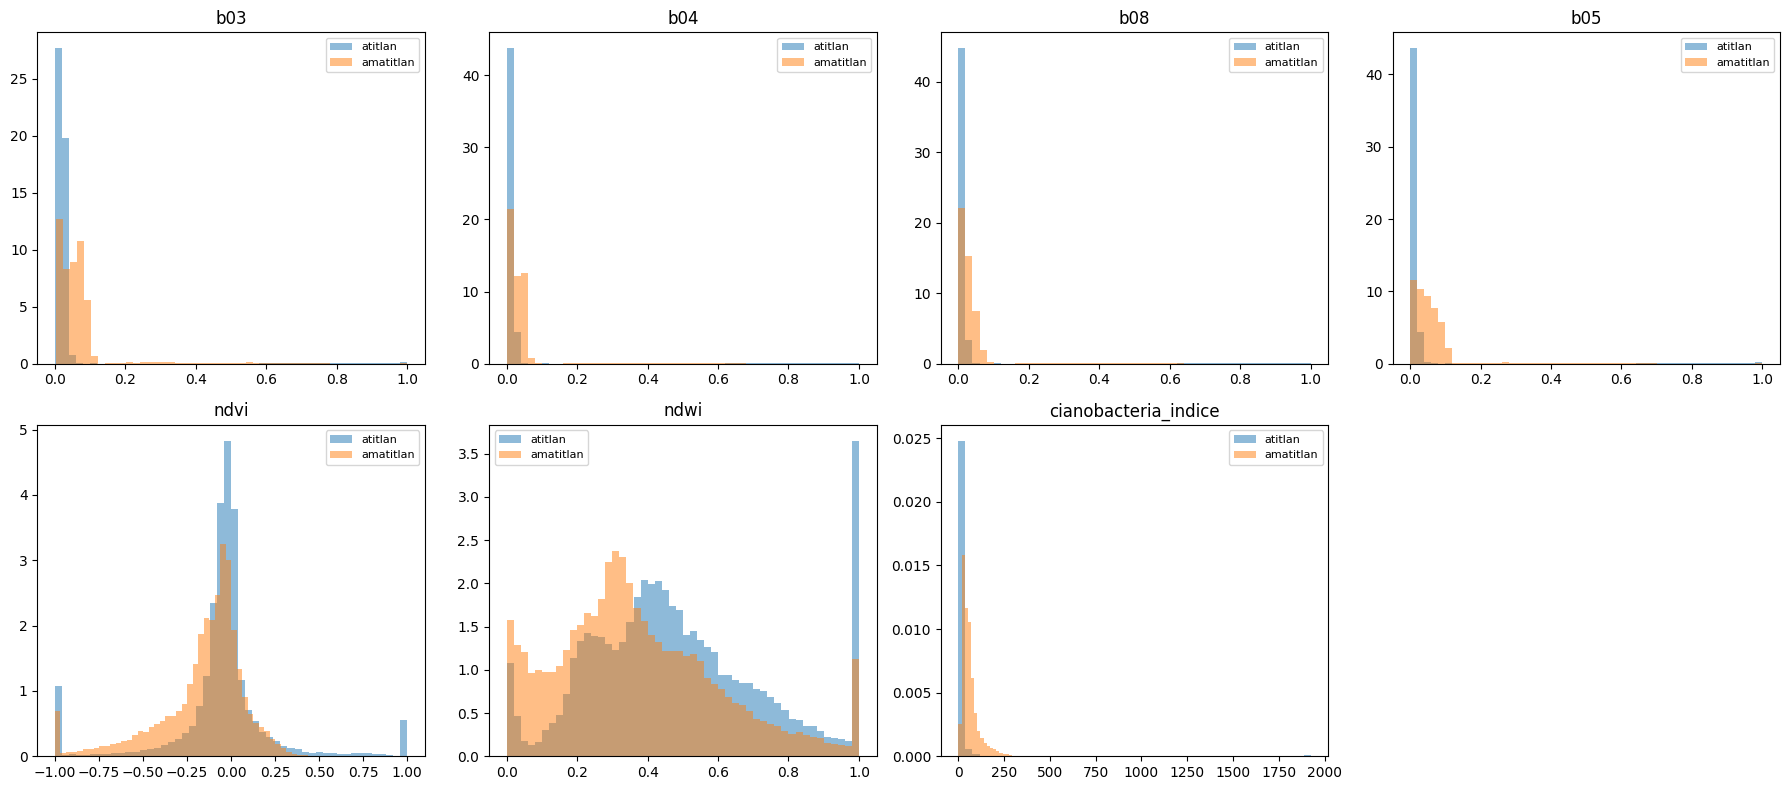

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, var in zip(axes, variables_numericas):
    for lago in df_ml["lago"].unique():
        sub = df_ml[df_ml["lago"] == lago][var]
        ax.hist(sub, bins=50, alpha=0.5, label=lago, density=True)
    ax.set_title(var)
    ax.legend(fontsize=8)
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("data/eda_histogramas_variables.png")
plt.show()

Confirman visualmente lo anterior: las cuatro bandas de reflectancia están casi todas amontonadas cerca de cero para ambos lagos, con muy pocos píxeles hacia valores altos, coherente con agua oscura en su mayoría. El NDVI se ve centrado cerca de cero con una ligera inclinación hacia negativos, más ese pequeño pico aislado en +1.0. El NDWI muestra dos "montañas": una hacia valores bajos-medios y otra grande cerca de 1.0, esa segunda agrupación cerca de 1.0 vale la pena revisarla, podría tratarse de zonas de agua muy profunda o muy calmada donde el índice se satura, y sería bueno confirmarlo antes de usarlo como variable en el modelo.

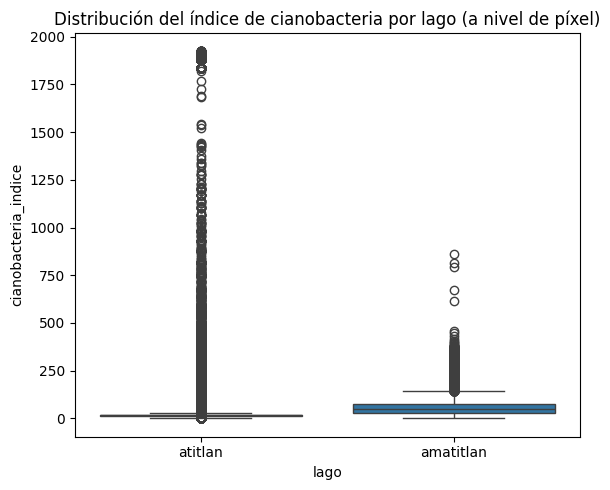

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df_ml, x="lago", y="cianobacteria_indice", ax=ax)
ax.set_title("Distribución del índice de cianobacteria por lago (a nivel de píxel)")
plt.tight_layout()
plt.savefig("data/eda_boxplot_cianobacteria.png")
plt.show()

Aquí se ve muy claro el contraste entre lagos, Atitlán tiene una caja (donde vive la mayoría de los datos) muy pegada al piso, pero una nube enorme de puntos atípicos que sube hasta casi 2,000, es decir, la gran mayoría del lago tiene niveles bajos, pero hay zonas puntuales con floraciones muy intensas. Amatitlán, en cambio, tiene una caja más alta y más ancha (su "normalidad" ya es más alta) pero con muchos menos extremos hacia arriba. Visualmente resume lo mismo que las estadísticas: Amatitlán como problema crónico y disperso, Atitlán como problema raro pero severo.

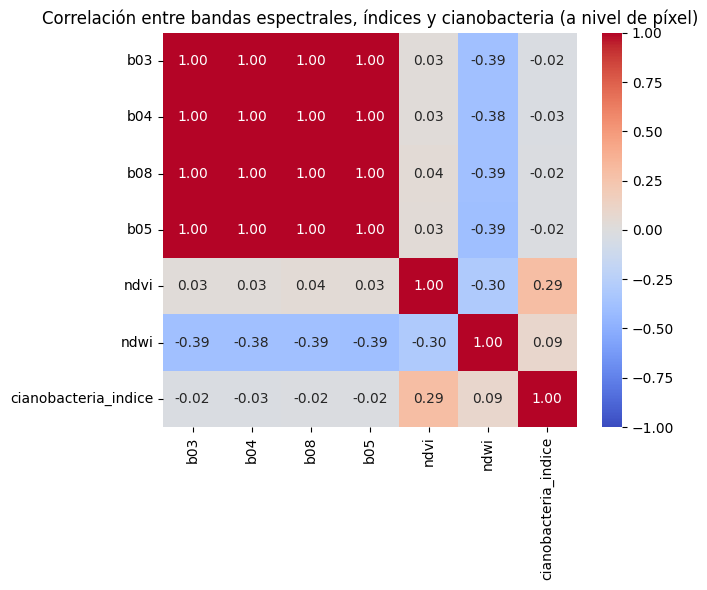

In [11]:
corr = df_ml[variables_numericas].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación entre bandas espectrales, índices y cianobacteria (a nivel de píxel)")
plt.tight_layout()
plt.savefig("data/eda_correlacion_variables.png")
plt.show()

Las cuatro bandas espectrales (b03, b04, b08, b05) están casi perfectamente correlacionadas entre sí (cercano a 1.00). Esto tiene sentido porque, a nivel de un solo píxel, todas responden más o menos al mismo factor: qué tan clara u oscura/turbia está el agua ahí, si sube una, suben casi todas juntas. Eso también nos dice que estas cuatro bandas, por sí solas, aportan información bastante repetida entre ellas.

En cuanto a la relación con la cianobacteria: el NDVI tiene una correlación positiva moderada (0.29), algo más útil que las bandas crudas. El NDWI, en cambio, tiene una correlación bastante débil con la cianobacteria a este nivel de píxel (0.09), mucho más débil que la relación que habían encontrado en la Parte I. Esto no es contradictorio, en la Parte I se correlacionaban promedios por fecha (11 puntos por lago, ya suavizados), mientras que aquí se está comparando píxel por píxel en las 620 mil observaciones, con mucho más ruido espacial de por medio. Las bandas crudas, por su parte, casi no muestran relación directa con la cianobacteria (cerca de 0), lo que sugiere que los índices derivados (sobre todo el NDVI) van a ser predictores más útiles que las bandas sin procesar.

### 1.6 Decisiones tomadas durante la preparación y limpieza de los datos

**Unidad de observación**: se trabajó a **nivel de píxel** (no de imagen completa),
  siguiendo lo pedido en el enunciado ("cada fila deberá representar una observación
  geográfica válida"). Esto da un dataset con variabilidad espacial explícita, útil
  para los modelos de clasificación de las siguientes secciones.

**Submuestreo espacial (`PIXEL_STRIDE = 5`)**: a resolución nativa de 10 m, cada
  imagen completa tiene del orden de millones de píxeles dentro del bounding box, y los
  píxeles vecinos están muy correlacionados espacialmente (casi no aportan información
  nueva). Por eso se toma 1 de cada 5 píxeles en filas y columnas (equivalente a una
  resolución efectiva de 50 m), lo que reduce el tamaño del dataset manteniendo
  cobertura espacial completa de ambos lagos y las 11 fechas. Este valor es ajustable.

**Límite del lago aproximado por NDWI**: al no contar con un polígono oficial de cada
  lago, se usó la máscara de agua (`NDWI > 0`) ya utilizada en la Parte I como proxy del
  límite físico del lago, y se aplicó de forma consistente en las 22 imágenes.

**Coordenadas en lon/lat (EPSG:4326)**: se guardaron en el sistema geográfico estándar
  para facilitar la inspección y el mapeo; la reproyección a un sistema métrico
  (EPSG:32615, UTM 15N) se hará en el ejercicio de validación espacial más adelante,
  como pide el enunciado.

**Nubes**: no se aplicó un filtro de nubes a nivel de píxel porque no se descargó la
  banda `SCL`. La exposición a nubes ya se había limitado en la Parte I
  (`max_cloud_cover <= 20%` por imagen). Se deja como posible variable adicional a
  incorporar en el ejercicio 3 si se decide descargar `SCL`.

**Manejo de NoData**: cualquier píxel con reflectancia inválida (`<= -1000`) o con
  algún índice no finito se excluyó por completo del dataset, en lugar de imputarlo,
  para no introducir observaciones artificiales en un problema ambiental donde la
  posición espacial es relevante.